# Computer Vision Tutorial: Convolutional Neural Networks (CNN)


*   Adapted from the guided book chapter 3.7 "Project: Image Classification for Color Images"
*   Original code at book's website: https://github.com/moelgendy/deep_learning_for_vision_systems/blob/master/chapter_03/chapter_3_cifar10_cnn.ipynb


---

In this notebook, we train a CNN to classify images from the CIFAR-10 database.


## 1. Load CIFAR-10 Database

*   Dataset description available at: https://www.cs.toronto.edu/~kriz/cifar.html
*   Also, it is available at: https://keras.io/api/datasets/cifar10/

In [1]:
import keras
from keras.datasets import cifar10

# load the pre-shuffled train and test data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

I0000 00:00:1772935419.858979   22376 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1772935421.452702   22376 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1772935424.900878   22376 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


/home/ervin/Desktop/notebooks_taller1/venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


## 2. Visualize the First 24 Training Images

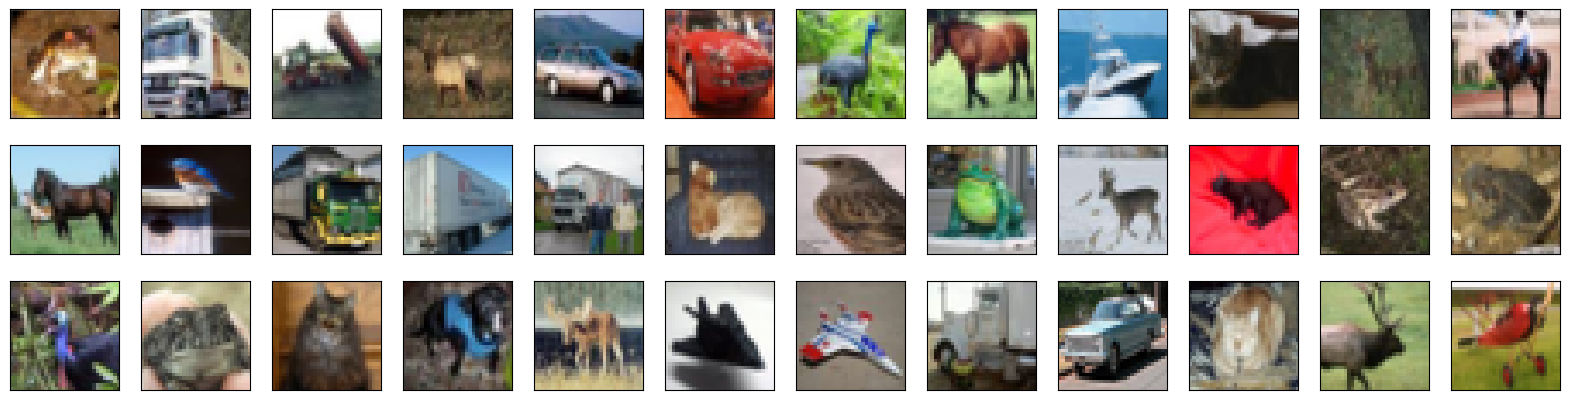

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

fig = plt.figure(figsize=(20,5))
for i in range(36):
    ax = fig.add_subplot(3, 12, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(x_train[i]))

## 3. **Image preprocessing**

### 3.1. Rescale the Images by Dividing Every Pixel in Every Image by 255


In [ ]:
# rescale [0,255] --> [0,1]
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

### 3.2.  Break Dataset into Training, Testing, and Validation Sets

* Prepare the labels using **One Hot Encoding**.
* Split the data into train, validation and test datasets.

In [61]:
# one-hot encode the labels
num_classes = len(np.unique(y_train))
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# break training set into training and validation sets
(x_train, x_valid) = x_train[5000:], x_train[:5000]
(y_train, y_valid) = y_train[5000:], y_train[:5000]

# print shape of training set
print('x_train shape:', x_train.shape)

# print number of training, validation, and test images
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')
print(x_valid.shape[0], 'validation samples')

x_train shape: (40000, 32, 32, 3)
40000 train samples
10000 test samples
5000 validation samples


### 4. Define the CNN Model Architecture



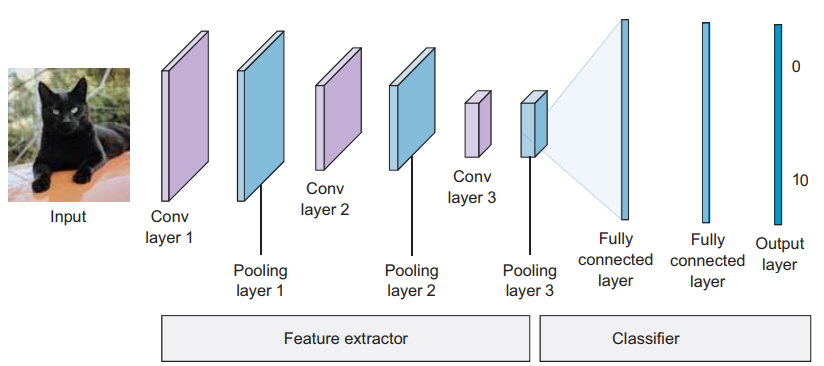

In [37]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()
model.add(Conv2D(filters=16, kernel_size=2, padding='same', activation='relu',
                        input_shape=(32, 32, 3)))
model.add(MaxPooling2D(pool_size=2))
model.add(Conv2D(filters=32, kernel_size=2, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Conv2D(filters=64, kernel_size=2, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(500, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 16)     │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 32)     │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 64)       │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 500)            │       512,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 528,054 (2.01 MB)

 Trainable params: 528,054 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

### 5. Compile the Model

The last step before training our model is to define three more hyperparameters to monitor during training and testing:

* Loss (error) function: How the network will be able to measure its performance on the
training data.
* Optimizer: The mechanism that the network will use to optimize its parameters
(weights and biases) to yield the minimum loss value. It is usually one of the
variants of stochastic gradient descent.

* Metrics: List of metrics to be evaluated by the model during training and testing. Typically we use metrics=['accuracy'].

In [38]:
# compile the model
model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

### 6. Train the Model

In [44]:
from keras.callbacks import ModelCheckpoint

# train the model
checkpointer = ModelCheckpoint(filepath='model.best.weights.h5', verbose=1,save_weights_only=True)

hist = model.fit(x_train, y_train, batch_size=32, epochs=3,
          validation_data=(x_valid, y_valid), callbacks=[checkpointer],
          verbose=2, shuffle=True)

Epoch 1/3

Epoch 1: saving model to model.best.weights.h5
1407/1407 - 48s - 34ms/step - accuracy: 0.6494 - loss: 1.0062 - val_accuracy: 0.6714 - val_loss: 0.9433
Epoch 2/3

Epoch 2: saving model to model.best.weights.h5
1407/1407 - 49s - 35ms/step - accuracy: 0.6626 - loss: 0.9756 - val_accuracy: 0.6848 - val_loss: 0.9188
Epoch 3/3

Epoch 3: saving model to model.best.weights.h5
1407/1407 - 82s - 58ms/step - accuracy: 0.6721 - loss: 0.9532 - val_accuracy: 0.6896 - val_loss: 0.8749


Check learning curves of model accuracy and loss values

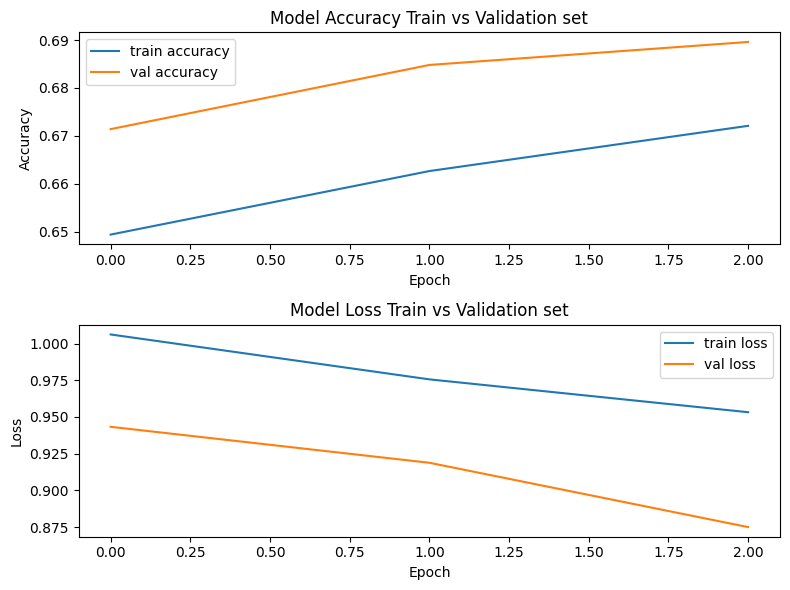

In [55]:
# plot learning curves of model

plt.figure(figsize=(8, 6))

# ---- Subplot 1: Accuracy ----
plt.subplot(2, 1, 1)
plt.plot(hist.history['accuracy'], label='train accuracy')
plt.plot(hist.history['val_accuracy'], label='val accuracy')
plt.title('Model Accuracy Train vs Validation set')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# ---- Subplot 2: Loss ----
plt.subplot(2, 1, 2)
plt.plot(hist.history['loss'], label='train loss')
plt.plot(hist.history['val_loss'], label='val loss')
plt.title('Model Loss Train vs Validation set')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

### 7. Evaluation of the trained model

#### 7.1. Load the Model with the Best Validation Accuracy

In [56]:
# load the weights that yielded the best validation accuracy
model.load_weights('model.best.weights.h5')

#### 7.2. Calculate Classification Accuracy on Test Set

In [57]:
# evaluate and print test accuracy
score = model.evaluate(x_test, y_test, verbose=0)
print('\n', 'Test accuracy:', score[1])


 Test accuracy: 0.6912000179290771


#### 7.3. Visualize Some Predictions

This may give you some insight into why the network is misclassifying certain objects.

In [58]:
# get predictions on the test set
y_hat = model.predict(x_test)

# define text labels (source: https://www.cs.toronto.edu/~kriz/cifar.html)
cifar10_labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


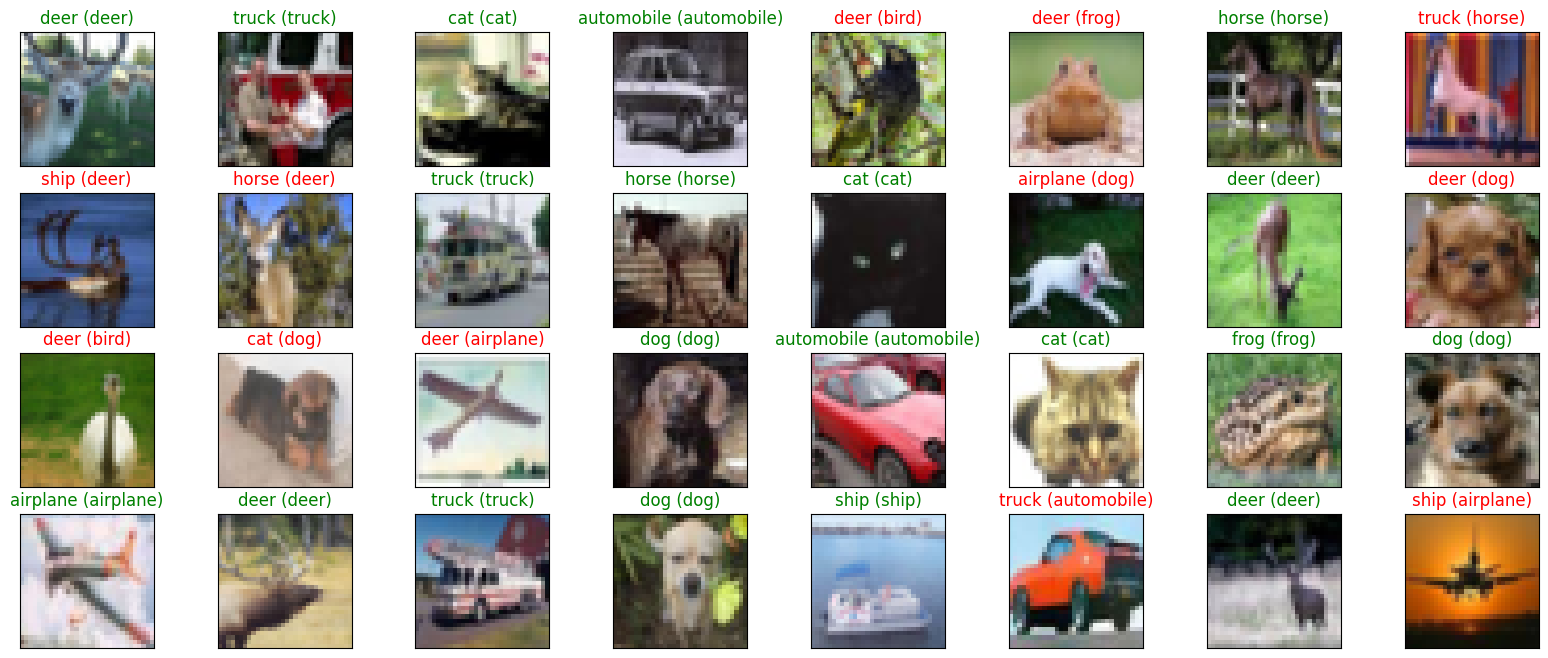

In [60]:
# plot a random sample of test images, their predicted labels, and ground truth
fig = plt.figure(figsize=(20, 8))
for i, idx in enumerate(np.random.choice(x_test.shape[0], size=32, replace=False)):
    ax = fig.add_subplot(4, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(x_test[idx]))
    pred_idx = np.argmax(y_hat[idx])
    true_idx = np.argmax(y_test[idx])
    ax.set_title("{} ({})".format(cifar10_labels[pred_idx], cifar10_labels[true_idx]),
                 color=("green" if pred_idx == true_idx else "red"))